# Name: Ananta Gurung
# ID: 2414247



In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

# Task 1: Data Understanding and Visualization:

In [2]:
# Get the list of class directories from the train folder.

DATASET_DIR = "/content/drive/MyDrive/AI and ML/week 6/FruitinAmazon/FruitinAmazon"

train_dir = os.path.join(DATASET_DIR, "train")
test_dir = os.path.join(DATASET_DIR, "test")

# List classes
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(classes)
print(f"\nClasses ({num_classes}): {classes}")

# Count images per class
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
    print(f"  {cls}: {count} images")


Classes (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
  acai: 15 images
  cupuacu: 15 images
  graviola: 15 images
  guarana: 15 images
  pupunha: 15 images
  tucuma: 15 images


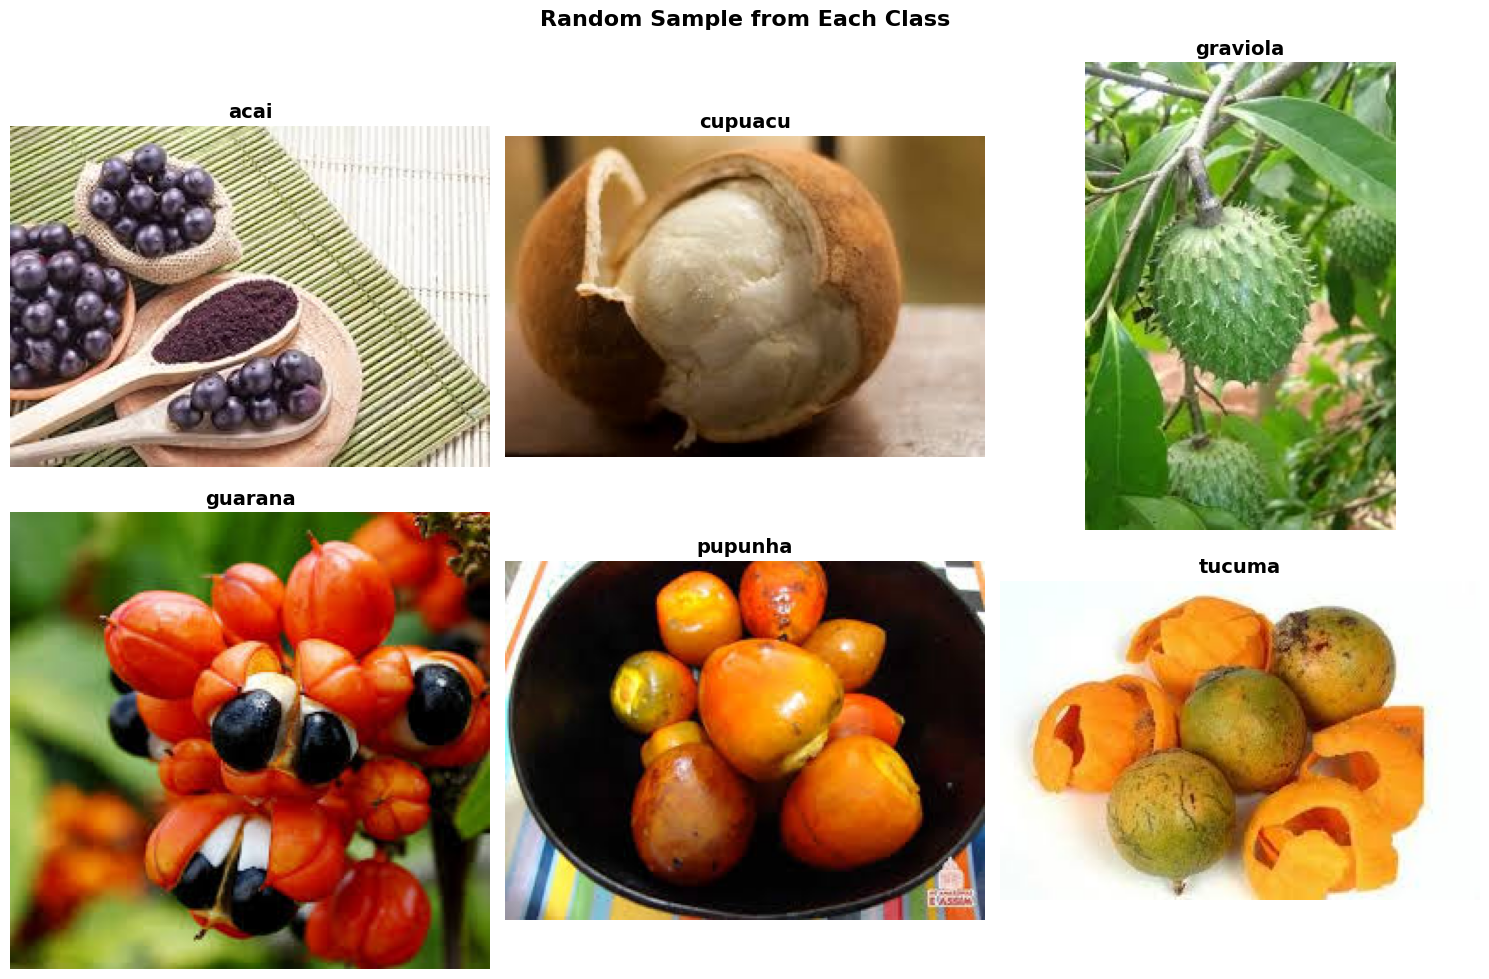

In [3]:
# Select one random image from each class and display in a grid
n_classes = len(classes)
cols = min(3, n_classes)
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
if rows == 1 and cols == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
    random_img = random.choice(img_files)
    img_path = os.path.join(cls_path, random_img)

    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(n_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle("Random Sample from Each Class", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**2. Check for Corrupted Image:**

In [4]:


DATASET_DIR = "/content/drive/MyDrive/AI and ML/week 5/FruitinAmazon"
train_dir = os.path.join(DATASET_DIR, "train")

corrupted_images = []

# Iterate through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Iterate through each image in the class folder
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            with Image.open(img_path) as img:
                img.verify()  # verify image integrity

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final output
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


# Task 2: Loading and Preprocessing Image Data in keras:

In [5]:
# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Create a preprocessing layer for normalization

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset="training",
  seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset="validation",
  seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Prefetch for performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 - Implement a CNN

In [6]:
model = Sequential([
    # Convolutional Layer 1
    Conv2D(32, (3, 3), activation='relu', padding='same', strides=1,
           input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    Conv2D(32, (3, 3), activation='relu', padding='same', strides=1),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully Connected Layers
    Flatten(),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the Model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


# Train the Model

In [8]:
# Callbacks
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.1250 - loss: 1.8877
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 538ms/step - accuracy: 0.1250 - loss: 1.9239 - val_accuracy: 0.8333 - val_loss: 1.3464
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.1377 - loss: 1.8537
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 0.1944 - loss: 1.8121 - val_accuracy: 0.0000e+00 - val_loss: 1.7176
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.3096 - loss: 1.6836
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 675ms/step - accuracy: 0.3194 - loss: 1.6761 - val_accuracy: 0.0000e+00 - val_loss: 1.7618
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.2089 - loss: 1.5449
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 648ms/step - accuracy: 0.2361 - loss: 1.5210 - val_accuracy: 0.7778 - val_loss: 1.3807
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.6094 - los


Epoch 15: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 514ms/step - accuracy: 0.9861 - loss: 0.0640 - val_accuracy: 0.8889 - val_loss: 0.4364
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 1.0000 - loss: 0.0680
Epoch 16: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 406ms/step - accuracy: 1.0000 - loss: 0.0562 - val_accuracy: 0.8333 - val_loss: 0.4061
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 1.0000 - loss: 0.0217
Epoch 17: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 1.0000 - loss: 0.0224 - val_accuracy: 0.8333 - val_loss: 0.5038
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 1.0000 - loss: 0.0213
Epoch 18: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 687ms/step - accuracy: 1.0000 - loss: 0.0195 - val_accuracy: 0.8333 - val_loss: 0.4654
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 1.0000 - los

# Task 5: Evaluate the Model

In [9]:
if test_dir and os.path.isdir(test_dir):
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(img_height, img_width),
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=False
    )
    test_ds = test_ds.map(lambda x, y: (rescale(x), y))
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)
    print("Separate test dataset loaded.")
else:
    # Use validation set as test set
    test_ds = val_ds
    print("No separate test directory — using validation set for evaluation.")

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")



Found 30 files belonging to 6 classes.
Separate test dataset loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.7000 - loss: 1.0493

Test Loss:     1.0493
Test Accuracy: 0.7000


**Visualization**

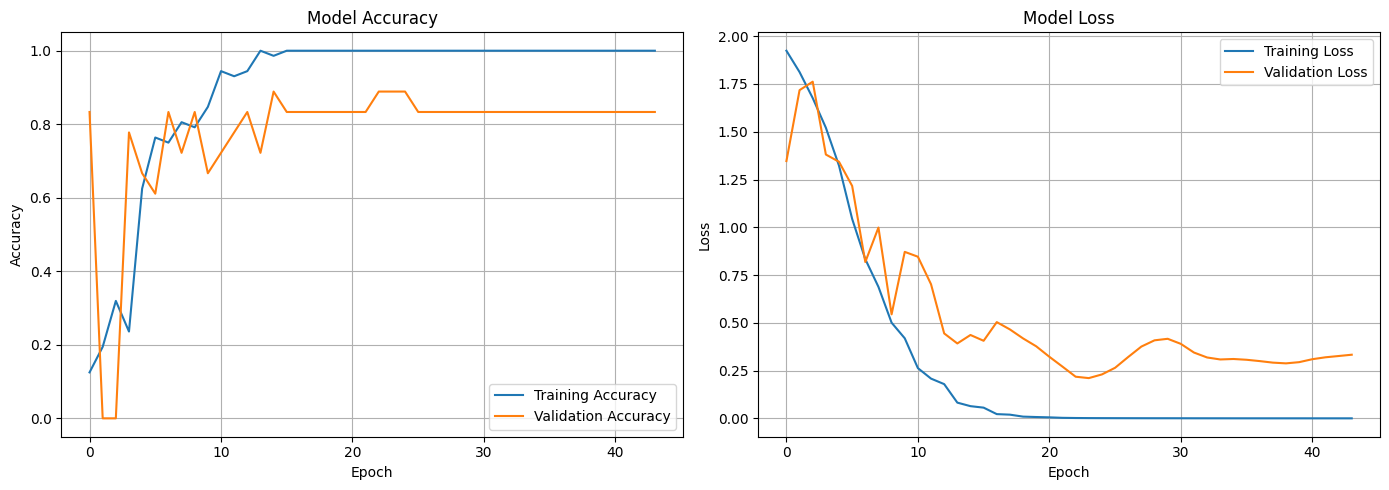

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Classification Report**

In [11]:
# Collect all predictions and true labels from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print("Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=classes))

Classification Report
              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.67      0.80      0.73         5
    graviola       0.80      0.80      0.80         5
     guarana       0.60      0.60      0.60         5
     pupunha       0.80      0.80      0.80         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.74      0.70      0.69        30
weighted avg       0.74      0.70      0.69        30



**Saved Model**

In [12]:
# Save
model.save('fruit_image_classifier_cnn.h5')
print("Model saved to 'fruit_image_classifier_cnn.h5'")

# Load
loaded_model = tf.keras.models.load_model('fruit_image_classifier_cnn.h5')
print("Model loaded successfully.")

# Re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"\nLoaded Model — Test Loss:     {loaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy: {loaded_acc:.4f}")

Model saved to 'fruit_image_classifier_cnn.h5'


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step - accuracy: 0.7000 - loss: 1.0493

Loaded Model — Test Loss:     1.0493
Loaded Model — Test Accuracy: 0.7000


# Data Augmentation to increase the number of training image

In [20]:
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)

In [16]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2
SEED        = 42

# Raw datasets — NO manual rescaling here; rescaling will live inside the model
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

# Cache & prefetch for performance
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# Quick shape check
for images, labels in train_ds.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Images batch shape: (32, 128, 128, 3)
Labels batch shape: (32,)


In [17]:
# Define augmentation layers (new API — runs on GPU during training)
data_augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

print("Data augmentation pipeline defined with", len(data_augmentation_layers), "transformations.")

Data augmentation pipeline defined with 5 transformations.


Visalise augmented images

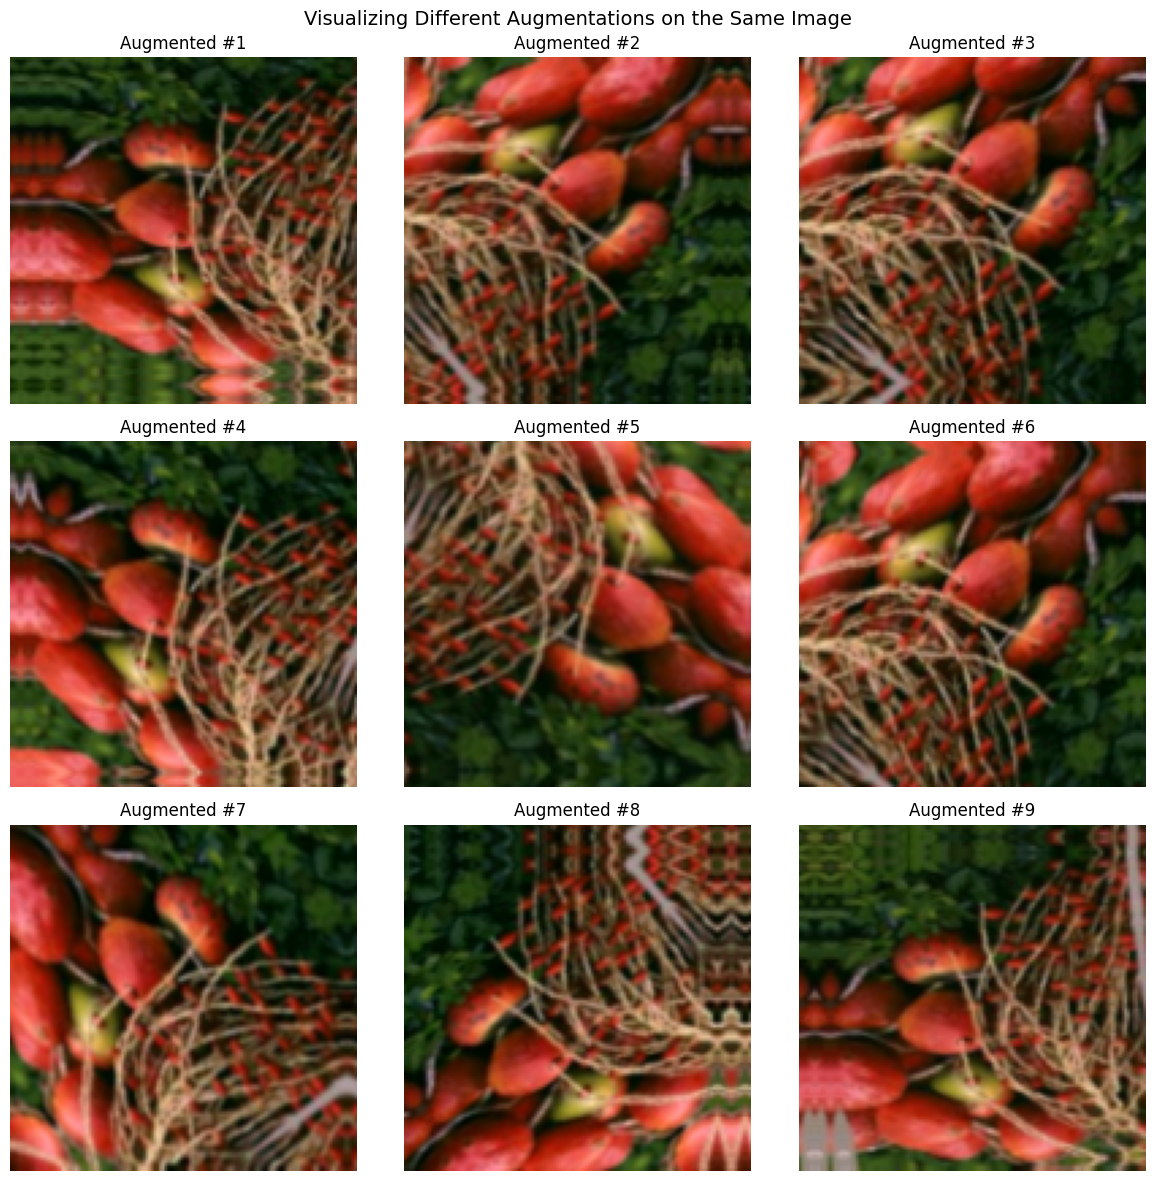

In [18]:
plt.figure(figsize=(12, 12))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented[0]).astype("uint8"))
        plt.title(f"Augmented #{i+1}")
        plt.axis("off")
plt.suptitle("Visualizing Different Augmentations on the Same Image", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)

model_cnn = Sequential([
    # ── Input + Augmentation + Rescaling ──────────────────────────────────────
    layers.Input(shape=input_shape),
    layers.Lambda(data_augmentation),          # Augmentation (active only during fit)
    layers.Rescaling(1./255),                  # Normalize [0,255] → [0,1]

    # ── Conv Block 1 (32 filters) ─────────────────────────────────────────────
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 2 (64 filters) ─────────────────────────────────────────────
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 3 (128 filters) ────────────────────────────────────────────
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 4 (256 filters) ────────────────────────────────────────────
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Flatten ───────────────────────────────────────────────────────────────
    Flatten(),

    # ── Dense Block 1 ─────────────────────────────────────────────────────────
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Dense Block 2 ─────────────────────────────────────────────────────────
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Dense Block 3 ─────────────────────────────────────────────────────────
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Dense Block 4 ─────────────────────────────────────────────────────────
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Output Layer ──────────────────────────────────────────────────────────
    Dense(num_classes, activation='softmax')
])

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             

 Total params: 8,956,166 (34.17 MB)

 Trainable params: 8,953,286 (34.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [22]:
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


In [23]:
checkpoint_cnn = ModelCheckpoint(
    'best_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_cnn = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history_cnn = model_cnn.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[checkpoint_cnn, early_stopping_cnn, reduce_lr],
    verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1343 - loss: 2.3988
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1528 - loss: 2.3983 - val_accuracy: 0.0000e+00 - val_loss: 1.7929 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1250 - loss: 2.2870
Epoch 2: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1250 - loss: 2.3005 - val_accuracy: 0.0000e+00 - val_loss: 1.7153 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1991 - loss: 2.3011
Epoch 3: val_accuracy improved from 0.00000 to 0.11111, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.2222 - loss: 2.2562 - val_accuracy: 0.1111 - val_loss: 1.7417 - learning_rate

In [24]:
# Load test dataset (fall back to val if no test folder)
if test_dir and os.path.isdir(test_dir):
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    ).prefetch(tf.data.AUTOTUNE)
    print("Separate test dataset loaded.")
else:
    test_ds = val_ds
    print("No separate test directory — using validation set for evaluation.")

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(test_ds)
print(f"\nCNN Test Loss:     {test_loss_cnn:.4f}")
print(f"CNN Test Accuracy: {test_acc_cnn:.4f}")

Found 30 files belonging to 6 classes.
Separate test dataset loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.1667 - loss: 1.7980

CNN Test Loss:     1.7980
CNN Test Accuracy: 0.1667


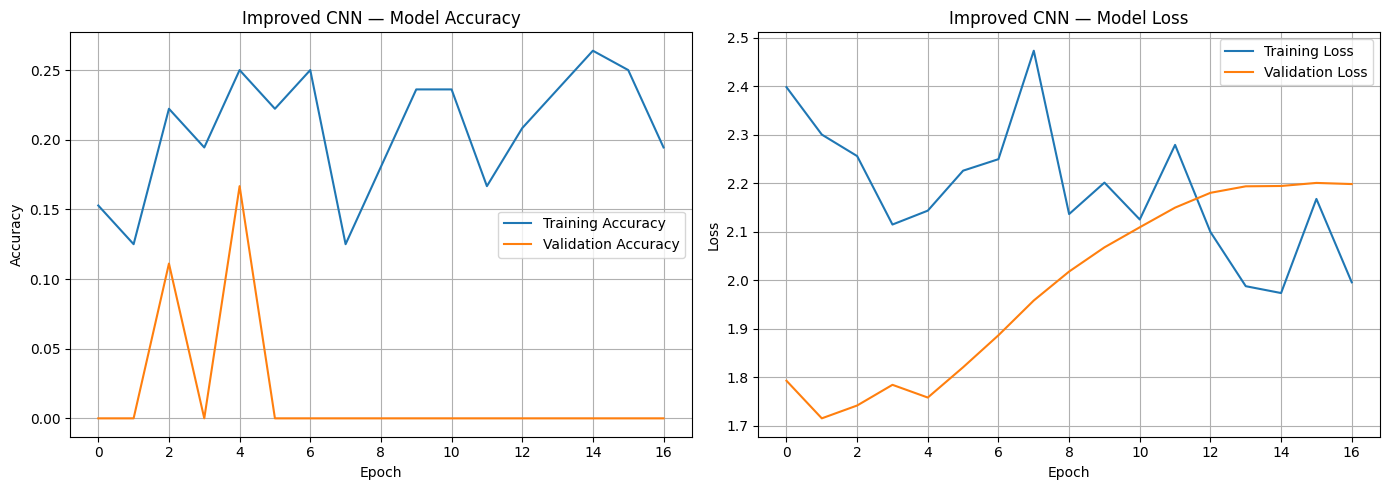

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cnn.history['accuracy'],     label='Training Accuracy')
ax1.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Improved CNN — Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_cnn.history['loss'],     label='Training Loss')
ax2.plot(history_cnn.history['val_loss'], label='Validation Loss')
ax2.set_title('Improved CNN — Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [34]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

In [30]:
VGG_IMG_SIZE = (224, 224)

train_ds_vgg = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=VGG_IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds_vgg = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=VGG_IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

# VGG16 preprocessing: scale to [0,1] then apply VGG16's own normalization
preprocess_input = tf.keras.applications.vgg16.preprocess_input

train_ds_vgg = train_ds_vgg.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds_vgg   = val_ds_vgg.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)

print("VGG16 datasets ready (224×224).")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
VGG16 datasets ready (224×224).


In [31]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,          # Exclude the original 1000-class head
    input_shape=(224, 224, 3)
)

print(f"VGG16 base loaded — total layers: {len(base_model.layers)}")
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base loaded — total layers: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
for layer in base_model.layers:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
frozen_count    = sum(1 for l in base_model.layers if not l.trainable)
print(f"Frozen layers:    {frozen_count}")
print(f"Trainable layers: {trainable_count}")

Frozen layers:    19
Trainable layers: 0


In [35]:
x = base_model.output

# Reduce spatial dims to a single vector per image
x = GlobalAveragePooling2D()(x)

# Fully connected block with BN + Dropout for regularization
x = Dense(1024, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)

# Output layer
outputs = Dense(num_classes, activation='softmax')(x)

# Assemble final model
model_vgg = Model(inputs=base_model.input, outputs=outputs)

print("Custom head added.")
print(f"Total params: {model_vgg.count_params():,}")
print(f"Trainable params: {sum(np.prod(v.shape) for v in model_vgg.trainable_variables):,}")

Custom head added.
Total params: 15,509,062
Trainable params: 791,814


In [36]:
model_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),   # Lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("VGG16 transfer learning model compiled.")

VGG16 transfer learning model compiled.


In [37]:
checkpoint_vgg = ModelCheckpoint(
    'best_vgg16_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_vgg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

history_vgg = model_vgg.fit(
    train_ds_vgg,
    epochs=50,
    validation_data=val_ds_vgg,
    callbacks=[checkpoint_vgg, early_stopping_vgg, reduce_lr_vgg],
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2917 - loss: 1.7075 
Epoch 1: val_accuracy improved from None to 0.55556, saving model to best_vgg16_model.keras

Epoch 1: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 16s/step - accuracy: 0.2500 - loss: 1.7717 - val_accuracy: 0.5556 - val_loss: 1.6889 - learning_rate: 1.0000e-04
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.2049 - loss: 2.0061 
Epoch 2: val_accuracy improved from 0.55556 to 0.61111, saving model to best_vgg16_model.keras

Epoch 2: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 16s/step - accuracy: 0.2083 - loss: 2.0175 - val_accuracy: 0.6111 - val_loss: 1.1646 - learning_rate: 1.0000e-04
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3490 - loss: 1.5964 
Epoch 3: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.3750 - loss: 1.5620 - val_accuracy: 0.6111 - val_loss: 0.9336

Evaluate the VGG16 Model


In [38]:
if test_dir and os.path.isdir(test_dir):
    test_ds_vgg = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=VGG_IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    ).map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
else:
    test_ds_vgg = val_ds_vgg
    print("No separate test directory — using validation set.")

test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_ds_vgg)
print(f"\nVGG16 Test Loss:     {test_loss_vgg:.4f}")
print(f"VGG16 Test Accuracy: {test_acc_vgg:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.8333 - loss: 0.5047

VGG16 Test Loss:     0.5047
VGG16 Test Accuracy: 0.8333


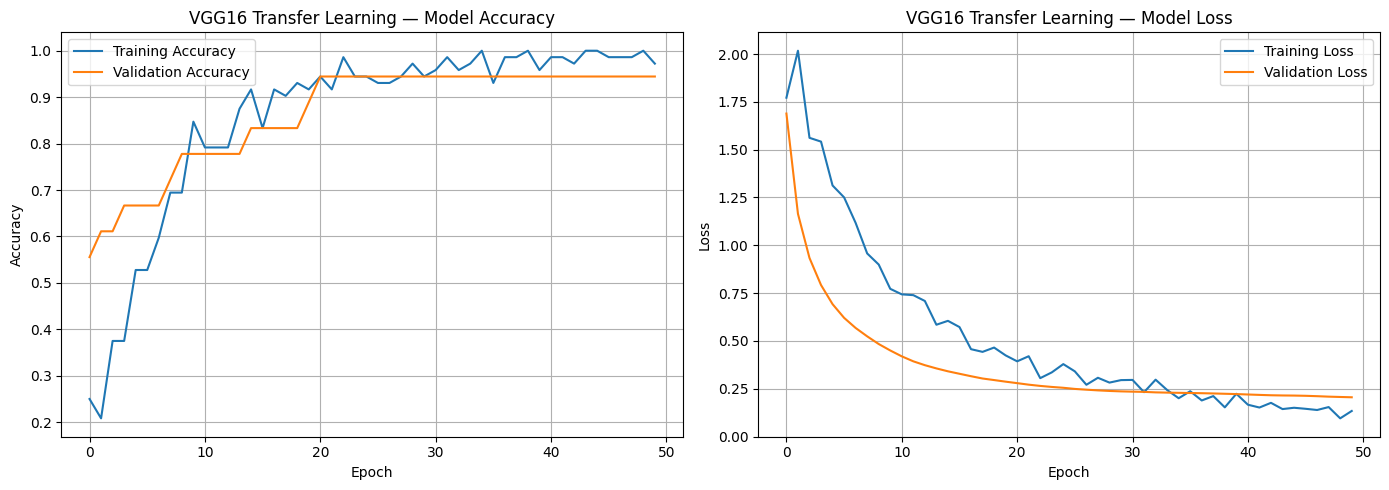

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_vgg.history['accuracy'],     label='Training Accuracy')
ax1.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('VGG16 Transfer Learning — Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_vgg.history['loss'],     label='Training Loss')
ax2.plot(history_vgg.history['val_loss'], label='Validation Loss')
ax2.set_title('VGG16 Transfer Learning — Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Classification report

In [41]:
y_true_vgg, y_pred_vgg = [], []

for images, labels in test_ds_vgg:
    preds = model_vgg.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

print("Classification Report — VGG16 Transfer Learning")
print("=" * 70)
print(classification_report(y_true_vgg, y_pred_vgg, target_names=classes))

Classification Report — VGG16 Transfer Learning
              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       1.00      0.80      0.89         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      1.00      1.00         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.83        30
   macro avg       0.85      0.83      0.84        30
weighted avg       0.85      0.83      0.84        30



Model Comparision

In [43]:

print(f"{'Model':<35} {'Test Accuracy':>12} {'Test Loss':>8}")

print(f"{'CNN + BN + Dropout + Augment':<35} {test_acc_cnn:>12.4f} {test_loss_cnn:>8.4f}")
print(f"{'VGG16 Transfer Learning':<35} {test_acc_vgg:>12.4f} {test_loss_vgg:>8.4f}")
print("=" * 55)

if test_acc_vgg > test_acc_cnn:
    improvement = (test_acc_vgg - test_acc_cnn) * 100
    print(f"\n✅ VGG16 Transfer Learning outperforms the custom CNN by {improvement:.2f}% accuracy.")
    print("   This confirms that leveraging pre-trained ImageNet features significantly")
    print("   boosts performance, especially on a small dataset like FruitinAmazon.")
else:
    print("\n⚠️  Custom CNN matched or outperformed VGG16 on this run.")
    print("   Consider fine-tuning VGG16's top layers for further gains.")


Model                               Test Accuracy Test Loss
CNN + BN + Dropout + Augment              0.1667   1.7980
VGG16 Transfer Learning                   0.8333   0.5047

✅ VGG16 Transfer Learning outperforms the custom CNN by 66.67% accuracy.
   This confirms that leveraging pre-trained ImageNet features significantly
   boosts performance, especially on a small dataset like FruitinAmazon.


Save the model

In [44]:
model_vgg.save('fruit_classifier_vgg16_transfer.keras')
print("VGG16 transfer learning model saved.")

loaded_vgg = keras.models.load_model('fruit_classifier_vgg16_transfer.keras')
loaded_loss_vgg, loaded_acc_vgg = loaded_vgg.evaluate(test_ds_vgg)
print(f"Loaded VGG16 model — Test Loss: {loaded_loss_vgg:.4f} | Test Accuracy: {loaded_acc_vgg:.4f}")

VGG16 transfer learning model saved.
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.8333 - loss: 0.5047
Loaded VGG16 model — Test Loss: 0.5047 | Test Accuracy: 0.8333
